# Notebook 4: Cost Prediction (Local)

**Goal:** Predict repair cost (INR) given `(damage_type, severity, area_pct)`.

**Two components:**
1. **Cost lookup table** — hand-crafted `(damage_type, severity) → base_cost` for the 14 detection classes
2. **Regression model** — Random Forest trained on synthetic data derived from the lookup + realistic noise

No GPU needed. Whole notebook runs in ~1 minute.

**Refine before Review-1:** validate the lookup table with 2-3 local garage surveys.


## 1. Cost reference table

In [1]:
import pandas as pd, os

# Base repair costs in INR — starting estimates for a mid-range sedan
COST_TABLE = {
    'bonnet-dent':             {'minor': 2500, 'moderate': 8000,  'severe': 25000},
    'boot-dent':               {'minor': 2500, 'moderate': 8000,  'severe': 22000},
    'doorouter-dent':          {'minor': 3000, 'moderate': 10000, 'severe': 28000},
    'fender-dent':             {'minor': 2500, 'moderate': 9000,  'severe': 24000},
    'front-bumper-dent':       {'minor': 3500, 'moderate': 12000, 'severe': 35000},
    'quaterpanel-dent':        {'minor': 3000, 'moderate': 11000, 'severe': 30000},
    'rear-bumper-dent':        {'minor': 3500, 'moderate': 12000, 'severe': 32000},
    'roof-dent':               {'minor': 4000, 'moderate': 14000, 'severe': 45000},
    'Front-windscreen-damage': {'minor': 3000, 'moderate': 12000, 'severe': 25000},
    'Rear-windscreen-Damage':  {'minor': 2500, 'moderate': 10000, 'severe': 20000},
    'Headlight-damage':        {'minor': 4000, 'moderate': 15000, 'severe': 35000},
    'Taillight-Damage':        {'minor': 3000, 'moderate': 10000, 'severe': 25000},
    'Sidemirror-Damage':       {'minor': 1500, 'moderate': 5000,  'severe': 12000},
    'Runningboard-Damage':     {'minor': 2000, 'moderate': 7000,  'severe': 18000},
}

df_cost = pd.DataFrame(COST_TABLE).T
df_cost.columns = ['minor', 'moderate', 'severe']
print(df_cost)

os.makedirs('app', exist_ok=True)
df_cost.to_csv('app/cost_table.csv')
print("\nSaved: app/cost_table.csv")

                         minor  moderate  severe
bonnet-dent               2500      8000   25000
boot-dent                 2500      8000   22000
doorouter-dent            3000     10000   28000
fender-dent               2500      9000   24000
front-bumper-dent         3500     12000   35000
quaterpanel-dent          3000     11000   30000
rear-bumper-dent          3500     12000   32000
roof-dent                 4000     14000   45000
Front-windscreen-damage   3000     12000   25000
Rear-windscreen-Damage    2500     10000   20000
Headlight-damage          4000     15000   35000
Taillight-Damage          3000     10000   25000
Sidemirror-Damage         1500      5000   12000
Runningboard-Damage       2000      7000   18000

Saved: app/cost_table.csv


## 2. Lookup-based estimator

In [2]:
def estimate_cost_lookup(damage_type: str, severity: str, area_pct: float) -> float:
    if damage_type not in COST_TABLE:
        return 0.0
    base = COST_TABLE[damage_type][severity]
    area_mult = 0.7 + min(area_pct * 5, 0.8)  # 0.7 at ~0% area, up to 1.5 at 30%+
    return round(base * area_mult, -2)

examples = [
    ('front-bumper-dent', 'moderate', 0.05),
    ('Headlight-damage',  'severe',   0.03),
    ('Sidemirror-Damage', 'minor',    0.02),
    ('roof-dent',         'severe',   0.15),
]
for dt, sv, a in examples:
    print(f"{dt:26s} {sv:8s} area={a*100:4.1f}%  ->  INR {estimate_cost_lookup(dt, sv, a):>8,.0f}")

front-bumper-dent          moderate area= 5.0%  ->  INR   11,400
Headlight-damage           severe   area= 3.0%  ->  INR   29,800
Sidemirror-Damage          minor    area= 2.0%  ->  INR    1,200
roof-dent                  severe   area=15.0%  ->  INR   65,200


## 3. Synthetic training data for the regression model

In [3]:
import numpy as np
np.random.seed(42)

N = 5000
damage_types = list(COST_TABLE.keys())
severities = ['minor', 'moderate', 'severe']

rows = []
for _ in range(N):
    dt = np.random.choice(damage_types)
    sv = np.random.choice(severities, p=[0.4, 0.4, 0.2])
    area = np.random.beta(2, 8)
    base = COST_TABLE[dt][sv]
    area_mult = 0.7 + min(area * 5, 0.8)
    noise = np.random.normal(1.0, 0.15)
    cost = base * area_mult * max(0.6, noise)
    rows.append({'damage_type': dt, 'severity': sv, 'area_pct': area, 'cost_inr': cost})

df = pd.DataFrame(rows)
print(df.head())
print(f"\nMean cost: INR {df['cost_inr'].mean():,.0f}")
print(f"Range:     INR {df['cost_inr'].min():,.0f} - {df['cost_inr'].max():,.0f}")

         damage_type  severity  area_pct      cost_inr
0   rear-bumper-dent  moderate  0.288844  17744.523295
1  front-bumper-dent  moderate  0.102098  15708.031714
2  front-bumper-dent  moderate  0.205826  18599.613034
3   Taillight-Damage  moderate  0.096834  10926.177232
4   rear-bumper-dent     minor  0.156542   4606.383714

Mean cost: INR 14,510
Range:     INR 1,017 - 99,731


## 4. Train Random Forest

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = pd.get_dummies(df[['damage_type', 'severity', 'area_pct']],
                   columns=['damage_type', 'severity'])
y = df['cost_inr']
FEATURE_COLS = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  INR {mae:,.0f}")
print(f"RMSE: INR {rmse:,.0f}")
print(f"R²:   {r2:.3f}")

MAE:  INR 2,016
RMSE: INR 3,597
R²:   0.935


## 5. Feature importance

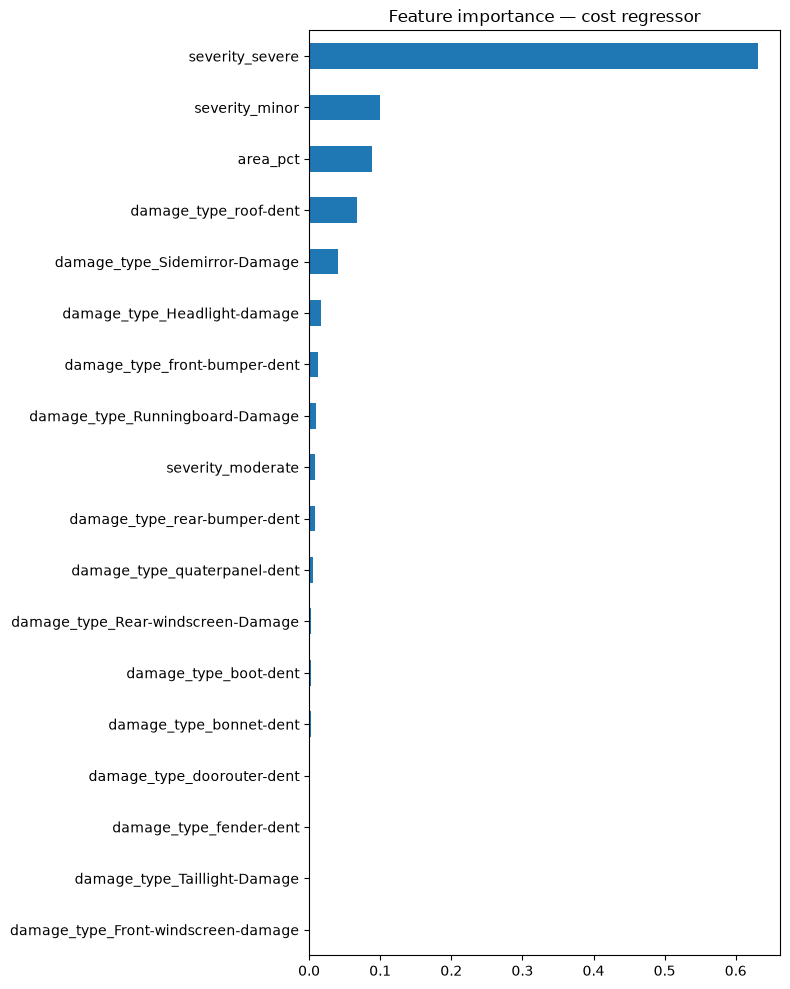

In [5]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
plt.figure(figsize=(8, 10))
importances.plot(kind='barh')
plt.title('Feature importance — cost regressor')
plt.tight_layout(); plt.show()

## 6. Save the model

In [6]:
import joblib

os.makedirs('models', exist_ok=True)
joblib.dump({
    'model': rf,
    'feature_cols': FEATURE_COLS,
    'damage_types': damage_types,
    'severities': severities,
}, 'models/cost_model.pkl')

print("Saved: models/cost_model.pkl")

Saved: models/cost_model.pkl


## 7. Sanity check ML predictions vs lookup

In [7]:
def estimate_cost_ml(damage_type, severity, area_pct):
    row = {c: 0 for c in FEATURE_COLS}
    row['area_pct'] = area_pct
    for key in (f'damage_type_{damage_type}', f'severity_{severity}'):
        if key in row: row[key] = 1
    x = pd.DataFrame([row])[FEATURE_COLS]
    return float(rf.predict(x)[0])

print(f"{'damage_type':26s} {'severity':10s} {'area':6s}  {'lookup':>9s}  {'ml':>9s}")
print("-" * 70)
for dt, sv, a in examples:
    lu = estimate_cost_lookup(dt, sv, a)
    ml = estimate_cost_ml(dt, sv, a)
    print(f"{dt:26s} {sv:10s} {a*100:4.1f}%  INR {lu:>6,.0f}  INR {ml:>6,.0f}")

damage_type                severity   area       lookup         ml
----------------------------------------------------------------------
front-bumper-dent          moderate    5.0%  INR 11,400  INR 10,739
Headlight-damage           severe      3.0%  INR 29,800  INR 27,579
Sidemirror-Damage          minor       2.0%  INR  1,200  INR  1,054
roof-dent                  severe     15.0%  INR 65,200  INR 67,218


## Done

- ✅ Cost reference table saved to `app/cost_table.csv`
- ✅ Random Forest saved to `models/cost_model.pkl`

**Honest note for the report:** the RF is trained on synthetic data derived from the lookup + noise. It interpolates smoothly but isn't discovering hidden pricing patterns. If you collect real garage-quote data, retrain the RF on that.

**Next:** Notebook 5 — chain all 3 models together and test end-to-end.